### 导入数据

In [3]:
import pandas as pd

column_names = ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']
df = pd.read_csv('UserBehavior.csv',names = column_names)
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100150807 entries, 0 to 100150806
Data columns (total 5 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        int64 
 1   item_id        int64 
 2   category_id    int64 
 3   behavior_type  object
 4   timestamp      int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ GB
None
   user_id  item_id  category_id behavior_type   timestamp
0        1  2268318      2520377            pv  1511544070
1        1  2333346      2520771            pv  1511561733
2        1  2576651       149192            pv  1511572885
3        1  3830808      4181361            pv  1511593493
4        1  4365585      2520377            pv  1511596146
            user_id       item_id   category_id     timestamp
count  1.001508e+08  1.001508e+08  1.001508e+08  1.001508e+08
mean   5.069431e+05  2.579775e+06  2.696380e+06  1.511951e+09
std    2.940605e+05  1.488056e+06  1.463155e+06  5.528006e+06
min    1.000000e+00  1.000000e+00  8.0

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### 数据清洗

In [5]:
#时间戳不直观，替换为日期
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

#拆分出日期和小时
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

#去除原本时间戳标记
df.drop('timestamp', axis=1, inplace=True)

In [6]:
#时间跨度修改
#官方定义时间跨度为 2017-11-25 至 2017-12-03
import datetime
start_date = datetime.date(2017, 11, 25)
end_date = datetime.date(2017, 12, 3)
#清除在时间跨度范围之外的数据
df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

print(df.isnull().sum()) #检查缺失值

user_id          0
item_id          0
category_id      0
behavior_type    0
datetime         0
date             0
hour             0
dtype: int64


### 数据分析

#### 用户行为分布

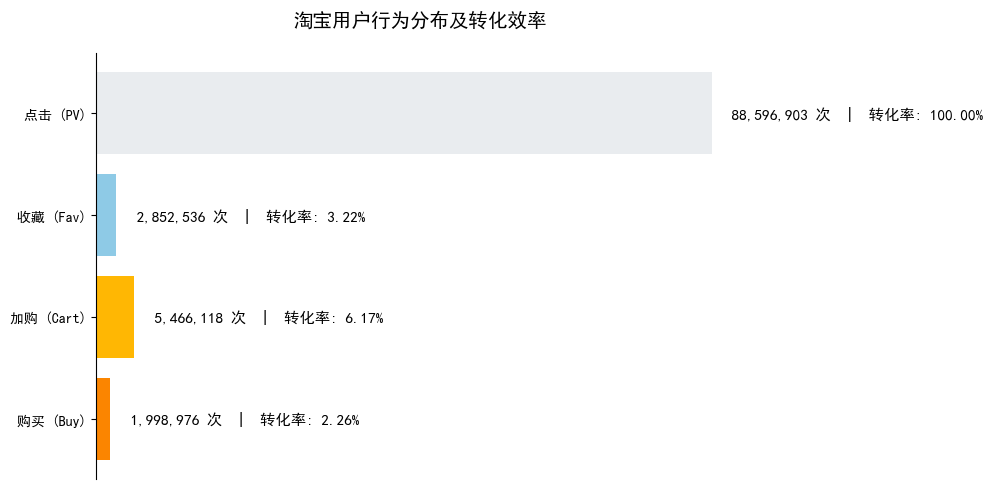

In [10]:
counts = df['behavior_type'].value_counts()

labels = ['点击 (PV)', '收藏 (Fav)', '加购 (Cart)', '购买 (Buy)']
values = [counts['pv'], counts['fav'], counts['cart'], counts['buy']]
rates = [100.0, (counts['fav']/counts['pv'])*100, (counts['cart']/counts['pv'])*100, (counts['buy']/counts['pv'])*100]

plt.figure(figsize=(10, 5))
plt.rcParams['font.sans-serif'] = ['SimHei']

bars = plt.barh(labels, values, color=['#e9ecef', '#8ecae6', '#ffb703', '#fb8500'])
plt.gca().invert_yaxis() 

for i, (v, r) in enumerate(zip(values, rates)):
    label_text = f" {v:,} 次  |  转化率: {r:.2f}%"
    plt.text(v + (max(values)*0.02), i, label_text, va='center', fontsize=11)

plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
plt.xticks([]) 
plt.title('淘宝用户行为分布及转化效率', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

####  淘宝用户行为转化分析报告

#### 核心转化数据统计
通过对数据集行为字段（`behavior_type`）的聚合分析，各阶段表现如下：

| 行为阶段 | 计数 (次) | 转化率 (对比PV) | 业务定义 |
| :--- | :--- | :--- | :--- |
| **点击 (PV)** | 88,595,203 | 100.00% | **基准流量**：用户进入平台的初始曝光 |
| **收藏 (Fav)** | 2,852,536 | **3.22%** | **潜在兴趣**：用户感兴趣但仍在观望 |
| **加购 (Cart)** | 5,466,118 | **6.17%** | **核心意向**：进入决策对比的关键环节 |
| **购买 (Buy)** | 1,998,976 | **2.26%** | **最终成交**：流量变现的终点 |

---

#### 关键业务洞察

*  漏斗极其“陡峭” 最终成交转化率仅为 **2.26%**。这表明淘宝具有极强的“逛街”属性，用户决策路径长，需要巨大的前端流量注入。
*  加购意向强于收藏 加购率（6.17%）几乎是收藏率（3.22%）的 **2 倍**。在业务上，购物车是比收藏夹更精准的成交预测指标。
*  临门一脚流失严重 虽然有超过 800 万次意向行为（收藏+加购），但最终转化率仅约 **25%**。说明大量用户在对比价格、凑单或受评价影响而放弃。

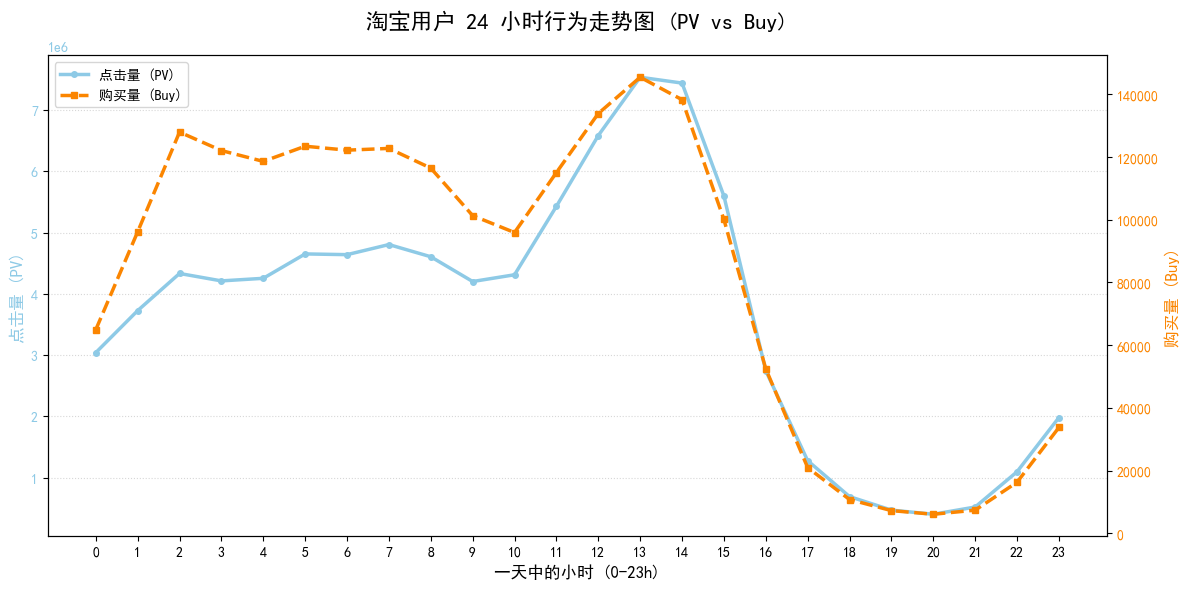

In [11]:
hour_behavior = df.groupby(['hour', 'behavior_type'])['user_id'].count().unstack()

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文乱码

ax1.plot(hour_behavior.index, hour_behavior['pv'], color='#8ecae6', label='点击量 (PV)', linewidth=2.5, marker='o', markersize=4)
ax1.set_xlabel('一天中的小时 (0-23h)', fontsize=12)
ax1.set_ylabel('点击量 (PV)', color='#8ecae6', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#8ecae6')

ax2 = ax1.twinx()
ax2.plot(hour_behavior.index, hour_behavior['buy'], color='#fb8500', label='购买量 (Buy)', linewidth=2.5, marker='s', markersize=4, linestyle='--')
ax2.set_ylabel('购买量 (Buy)', color='#fb8500', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#fb8500')

plt.title('淘宝用户 24 小时行为走势图 (PV vs Buy)', fontsize=16, pad=20)
ax1.set_xticks(range(0, 24))
ax1.grid(axis='y', linestyle=':', alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

####  运营建议
凌晨策略：针对深夜 0-2 点的高转化人群，可以设置“限时深夜福利”，利用其高决策效率转化流量。

午间推手：12:00-14:00 是白天的黄金期，适合进行直播预热或短视频种草。

避开低迷期：17:00-21:00 期间用户活跃度极低，建议减少广告竞价，保存预算给深夜和次日清晨。

### RF分析（基于RFM，但数据并未显示金额（M））

In [16]:
buy_df = df[df['behavior_type'] == 'buy']
user_buy_count = buy_df.groupby('user_id')['item_id'].count()

buy_once = user_buy_count[user_buy_count == 1].count() #仅一次购买人数
buy_multi = user_buy_count[user_buy_count >= 2].count()#复购人数
repurchase_rate = buy_multi / (buy_once + buy_multi)#复购率

print(f"仅购买一次的用户数: {buy_once}")
print(f"复购用户数 (2次及以上): {buy_multi}")
print(f"整体复购率: {repurchase_rate:.2%}")

仅购买一次的用户数: 229174
复购用户数 (2次及以上): 441196
整体复购率: 65.81%


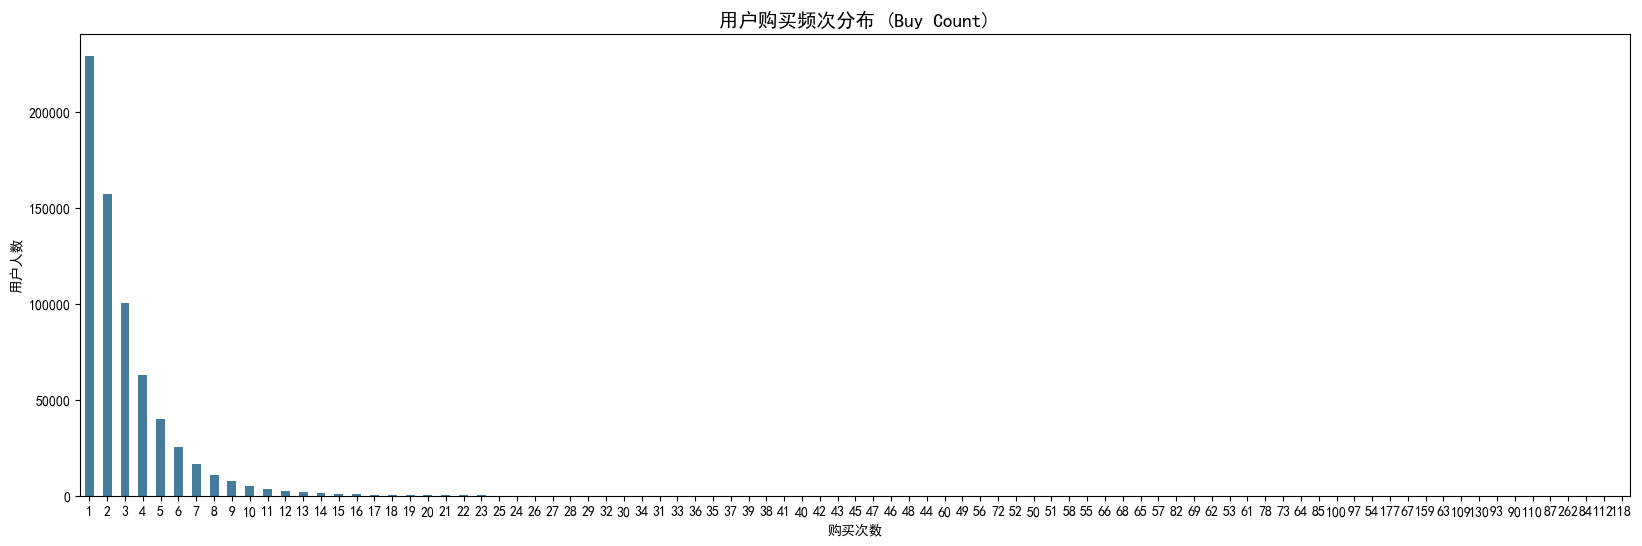

In [19]:
# 购买频次分布图
plt.figure(figsize=(20, 6))
user_buy_count.value_counts().plot(kind='bar', color='#457b9d')
plt.title('用户购买频次分布 (Buy Count)', fontsize=14)
plt.xlabel('购买次数')
plt.ylabel('用户人数')
plt.xticks(rotation=0)
plt.show()

图中显示购买次数过多的数据，怀疑为批发商、代购、刷单号或爬虫机器人，应当作出二次清洗

In [20]:
# 设定阈值：计算 99% 分位数
threshold = user_buy_count.quantile(0.99)
print(f"99% 分位线为: {threshold} 次 (超过此次数将被视为极端值)")

#  筛选掉极端活跃用户
normal_users = user_buy_count[user_buy_count <= threshold].index
df_filtered = df[df['user_id'].isin(normal_users)]

# 重新计算去噪后的复购率
buy_df_clean = df_filtered[df_filtered['behavior_type'] == 'buy']
user_buy_count_clean = buy_df_clean.groupby('user_id')['item_id'].count()

buy_once_clean = user_buy_count_clean[user_buy_count_clean == 1].count()
buy_multi_clean = user_buy_count_clean[user_buy_count_clean >= 2].count()
new_repurchase_rate = buy_multi_clean / (buy_once_clean + buy_multi_clean)

print(f"去噪后复购用户数: {buy_multi_clean}")
print(f"去噪后整体复购率: {new_repurchase_rate:.2%}")

99% 分位线为: 14.0 次 (超过此次数将被视为极端值)
去噪后复购用户数: 435849
去噪后整体复购率: 65.54%


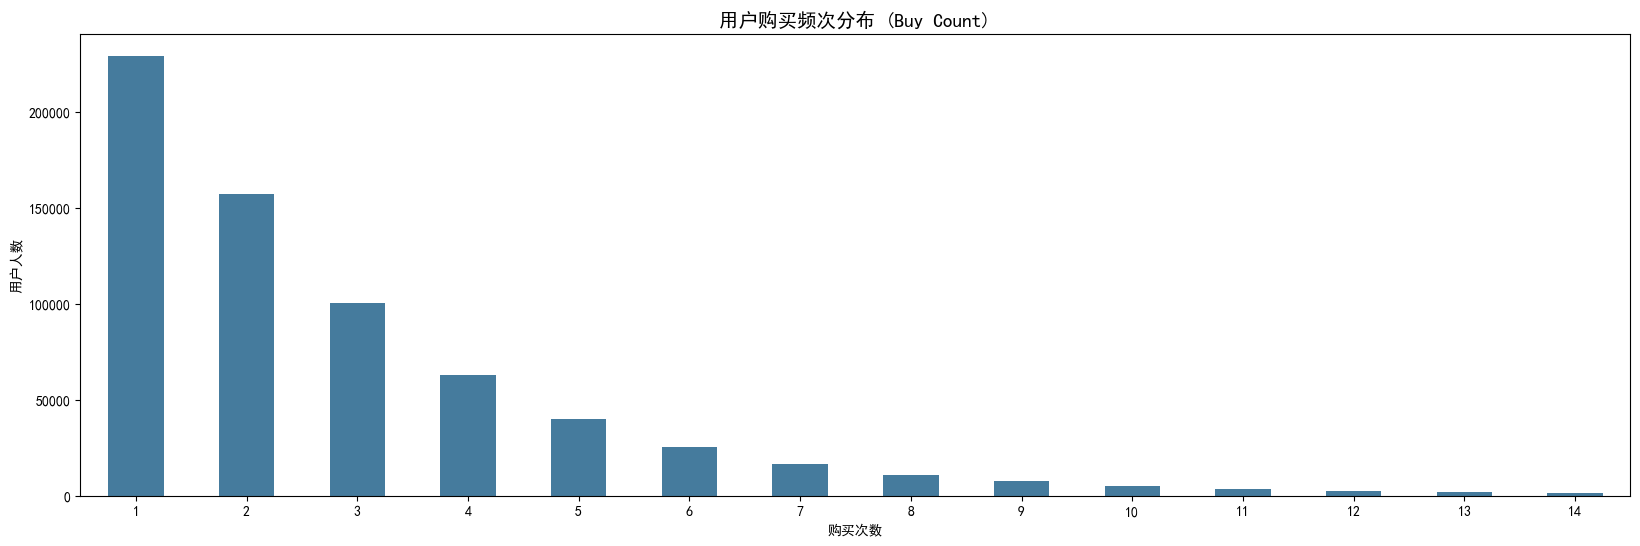

In [21]:
#再次绘图
plt.figure(figsize=(20, 6))
user_buy_count_clean.value_counts().plot(kind='bar', color='#457b9d')
plt.title('用户购买频次分布 (Buy Count)', fontsize=14)
plt.xlabel('购买次数')
plt.ylabel('用户人数')
plt.xticks(rotation=0)
plt.show()

####  基于真实用户的运营策略建议

1. **精准分层奖励**：
   - **对于买过 1 次的用户**：发放“二次回购券”，因为一旦跨过 1 次的门槛，他们有 65% 的概率成为核心复购客。
   - **对于买过 3-5 次的用户**：引导加入“包邮会员”或“周期购”，利用其高频需求锁定未来 3-6 个月的成交。

2. **营销节奏建议**：
   - 由于用户决策快且复购勤，营销短信或 App Push 的频率可以适当增加（如每 3 天一次），因为用户此时处于活跃的购买周期内。

3. **类目关联挖掘**：
   - 分析这些复购 5 次以上的用户都在买什么，如果是同类产品，考虑“囤货装”；如果是不同类目，说明是全能型优质用户，应加强全品类推荐。

#### 各商品类目复购率分析

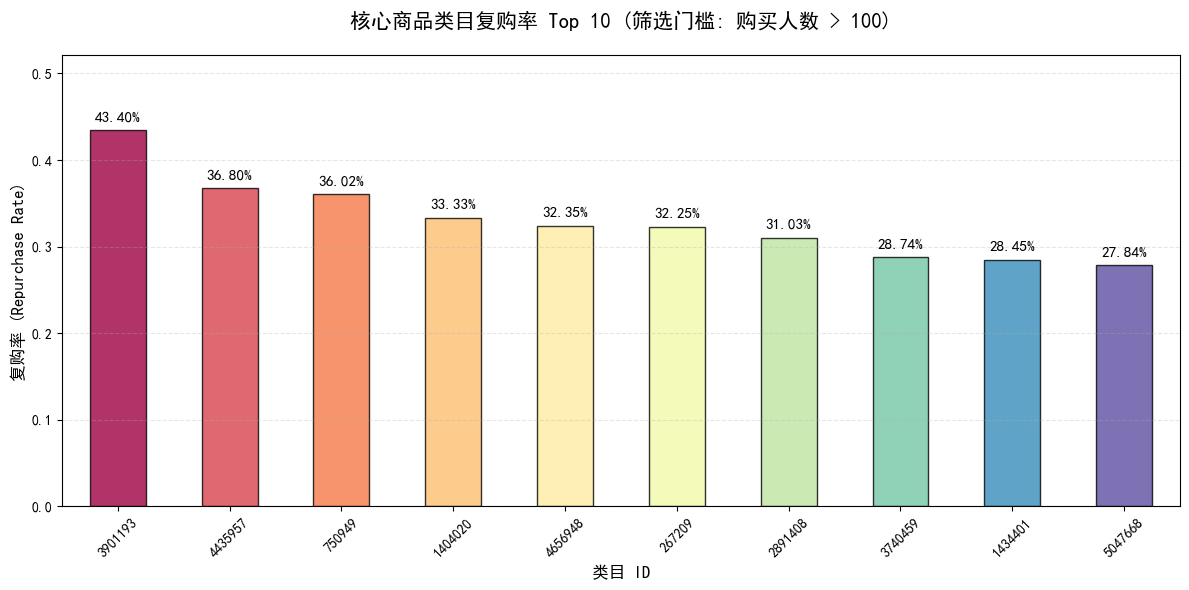

In [24]:
cat_user_buy = buy_df_clean.groupby(['category_id', 'user_id'])['item_id'].count().reset_index()
cat_total_users = cat_user_buy.groupby('category_id')['user_id'].count()
# 每个类目的复购人数（在该类目买过 >=2 次的人）
cat_re_users = cat_user_buy[cat_user_buy['item_id'] >= 2].groupby('category_id')['user_id'].count()

#设置门槛，避免长尾效应
min_people_threshold = 100 
qualified_cats = cat_total_users[cat_total_users > min_people_threshold].index

# 仅计算达标类目的复购率
valid_re_rate = (cat_re_users / cat_total_users).loc[qualified_cats].fillna(0)
top_10_valid_cat = valid_re_rate.sort_values(ascending=False).head(10)


#绘图
plt.figure(figsize=(12, 6))
plt.rcParams['font.sans-serif'] = ['SimHei']

colors = plt.colormaps['Spectral'](np.linspace(0, 1, 10))
bars = top_10_valid_cat.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

for i, v in enumerate(top_10_valid_cat):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold', fontsize=11)

plt.title(f'核心商品类目复购率 Top 10 (筛选门槛: 购买人数 > {min_people_threshold})', fontsize=15, pad=20)
plt.ylabel('复购率 (Repurchase Rate)', fontsize=12)
plt.xlabel('类目 ID', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(top_10_valid_cat) * 1.2) 

plt.tight_layout()
plt.show()

####  商品类目复购率深度诊断 (去噪后)

针对 **购买人数 > 100** 的核心类目进行复购率拆解，结果显示平台具备极强的品类粘性：

| 类目层级 | 代表类目 ID | 复购率 | 业务地位 | 经营建议 |
| :--- | :--- | :--- | :--- | :--- |
| **第一梯队** | `3901193` | **43.40%** | **核心压舱石** | 粘性全场最高。建议设为会员核心权益商品，或作为老客唤回的“钩子”品类。 |
| **第二梯队** | Top 2-5 类目 | **32% - 37%** | **稳定贡献者** | 属于高频购买区。尝试通过“买赠”或“周期购”锁定用户未来的购买份额。 |
| **第三梯队** | Top 6-10 类目 | **27% - 31%** | **潜力增长点** | 复购率远高于大盘平均水平。适合作为交叉销售（Cross-selling）的推荐项。 |

---

####  核心洞察 (Insights)

1. **品类护城河效应**：
   Top 1 类目 43.4% 的复购率意味着近半数买家会在 9 天内再次下单。这种极高的忠诚度说明该品类已形成强有力的用户心智占领，是平台的**流量保险柜**。

2. **高频拉动整体转化**：
   虽然大盘首单转化率仅 2.26%，但这些核心类目的二次留存能力极强。这意味着**“获客虽难，但留存极易”**。

3. **营销资源分配**：
   建议将促销预算向这些 Top 10 类目倾斜。相比于开发新类目，提升这些高粘性类目的曝光量，其 **LTV（用户终身价值）** 转化效率会更高。

In [26]:
# 计算 R 和 F 
buy_df = df_filtered[df_filtered['behavior_type'] == 'buy']
reference_date = buy_df['date'].max()
rfm = buy_df.groupby('user_id').agg({
    'date': lambda x: (reference_date - x.max()).days,
    'item_id': 'count'
}).rename(columns={'date': 'Recency', 'item_id': 'Frequency'})

# R 评分
def r_score(x):
    if x <= 1: return 4
    elif x <= 3: return 3
    elif x <= 7: return 2
    else: return 1

# F 评分
def f_score(x):
    if x >= 10: return 4
    elif x >= 5: return 3
    elif x >= 2: return 2
    else: return 1

rfm['R_score'] = rfm['Recency'].apply(r_score)
rfm['F_score'] = rfm['Frequency'].apply(f_score)

# 用户分类逻辑
def segment_user(row):
    r, f = row['R_score'], row['F_score']
    if r >= 3 and f >= 3: return '核心价值用户'
    elif r >= 3 and f < 3: return '新晋潜力用户'
    elif r < 3 and f >= 3: return '重要唤回用户'
    else: return '流失边缘用户'

rfm['User_Segment'] = rfm.apply(segment_user, axis=1)

# 查看结果
print(rfm['User_Segment'].value_counts())

User_Segment
新晋潜力用户    347092
流失边缘用户    202721
核心价值用户    101441
重要唤回用户     13769
Name: count, dtype: int64


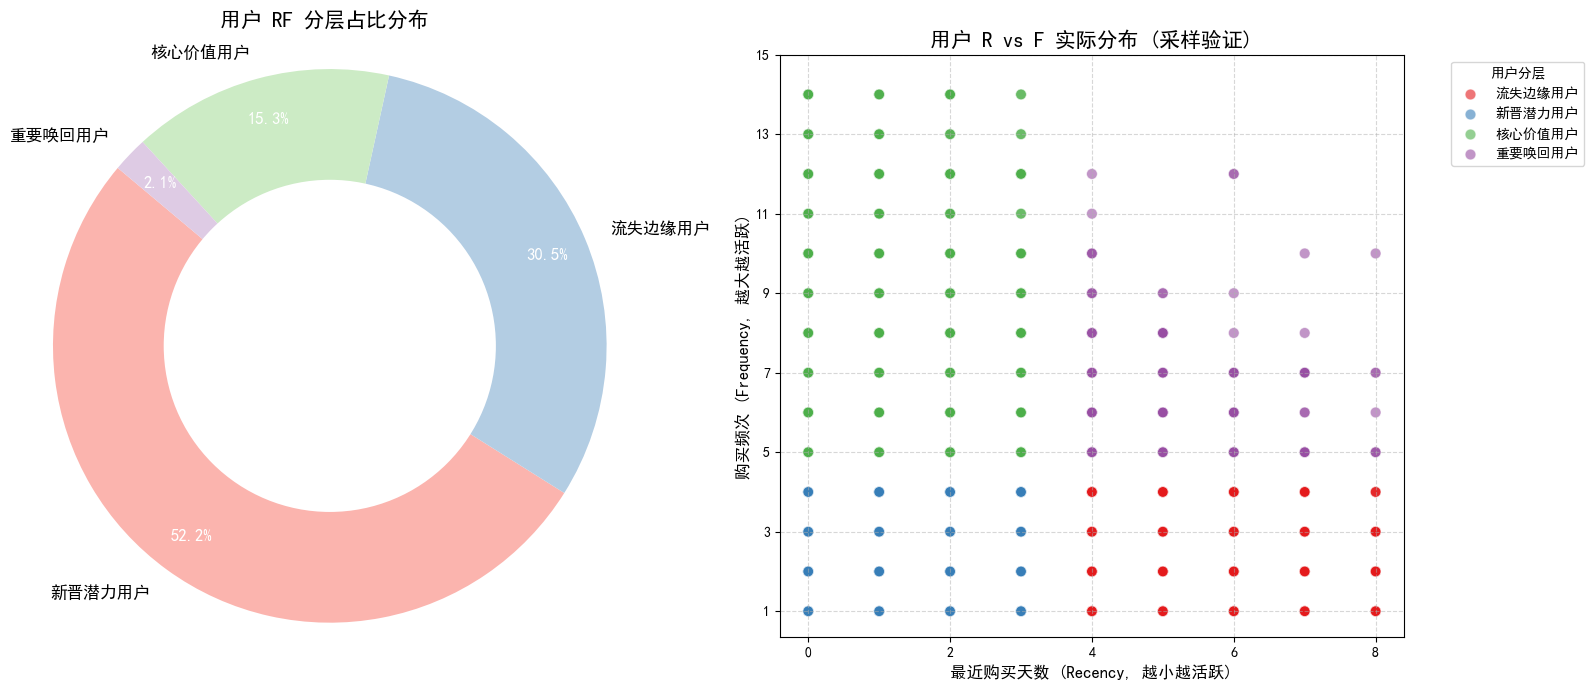

In [28]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

segment_counts = rfm['User_Segment'].value_counts()
segment_labels = segment_counts.index
segment_values = segment_counts.values

rfm_plot = rfm[rfm['Frequency'] <= 14].sample(10000, random_state=42) if len(rfm) > 10000 else rfm[rfm['Frequency'] <= 14]

fig = plt.figure(figsize=(16, 7))


# 用户分层占比饼图 
ax1 = fig.add_subplot(1, 2, 1) 
colors = plt.colormaps['Pastel1'](range(len(segment_counts)))


patches, texts, autotexts = ax1.pie(
    segment_values, 
    labels=segment_labels, 
    autopct='%1.1f%%',   
    startangle=140,    
    colors=colors,       
    pctdistance=0.85,    
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

centre_circle = plt.Circle((0,0),0.60,fc='white')
ax1.add_artist(centre_circle)

ax1.axis('equal') 
ax1.set_title('用户 RF 分层占比分布 ', fontsize=15, pad=20)


# R vs F 散点分布图 
ax2 = fig.add_subplot(1, 2, 2) 

sns.scatterplot(
    data=rfm_plot, 
    x='Recency',         
    y='Frequency',       
    hue='User_Segment',  
    palette='Set1',      
    s=60,                
    alpha=0.6,           #
    ax=ax2
)

ax2.set_title('用户 R vs F 实际分布 (采样验证)', fontsize=15)
ax2.set_xlabel('最近购买天数 (Recency, 越小越活跃)', fontsize=12)
ax2.set_ylabel('购买频次 (Frequency, 越大越活跃)', fontsize=12)
ax2.set_xticks(range(0, rfm_plot['Recency'].max() + 2, 2)) 
ax2.set_yticks(range(1, rfm_plot['Frequency'].max() + 2, 2)) 
ax2.grid(True, linestyle='--', alpha=0.5)

ax2.legend(title='用户分层', loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

#### 运营实战：基于 RFM 模型的人群精准营销策略

通过对用户分层数据的可视化分析，我们告别“盲目全场大促”，进入**“因人而异”**的精细化运营阶段。

#### 用户分层策略看板

| 用户群体 | 核心特征 (R/F) | 运营目标 | 落地实战策略 (Action Plan) |
| :--- | :--- | :--- | :--- |
| **核心价值用户** | **R小 (活跃)** <br> **F大 (频次高)** | **提高终身价值 (LTV)** | **无需发券**。提供非金钱激励：如专属客服绿色通道、新品优先内测权、社群身份标识，通过情感连接强化护城河。 |
| **重要唤回用户** | **R大 (流失预警)** <br> **F大 (曾经忠诚)** | **流失阻断/激活** | **重金召唤**。发放“老友回归大额满减券”或“限时0元礼包”。利用其对平台的存量认知，通过强价格刺激促其回访。 |
| **新晋潜力用户** | **R小 (新近购买)** <br> **F小 (频次尚低)** | **习惯培养** | **首单后置转化**。在确认收货后 24h 内精准推送“二次回购优惠券”。趁其购物热度未退，引导跨过高频复购的门槛。 |
| **流失边缘用户** | **R大 (长期沉默)** <br> **F小 (购买零星)** | **低成本唤起** | **低频触达**。仅在双11、618等年度大促时进行短信/Push 提醒。日常不投入过多营销成本，避免 ROI 过低。 |

---

####  核心执行要点

1. **ROI 最大化**：
   - 营销资源应优先向 **“重要唤回用户”** 倾斜，因为激活一个老客的成本远低于获取一个新客。
   - 避免对 **“核心价值用户”** 过度发券，防止形成“不发券就不下单”的利润侵蚀。

2. **时机控制**：
   - 对于 **“新晋潜力用户”**，其营销黄金期是在首单后的 **3-5 天** 内，根据其购买品类的消耗周期（参考前文类目分析）进行精准触达。

3. **数据闭环**：
   - 建议在执行策略 2 周后，重新运行 RFM 模型，对比各人群占比的变化，验证营销动作是否成功让“潜力用户”转变为“核心用户”。